--- 1. Preparación de Datos ---

--- 2. Ajuste de Hiperparámetros ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Mejores hiperparámetros encontrados: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Mejor puntuación R-squared en validación cruzada: 0.9201

--- 3. Entrenamiento y Evaluación del Modelo Final ---
MAE (Error Absoluto Medio) en datos de prueba: 1.5252
R-squared (Coeficiente de Determinación) en datos de prueba: 0.9202


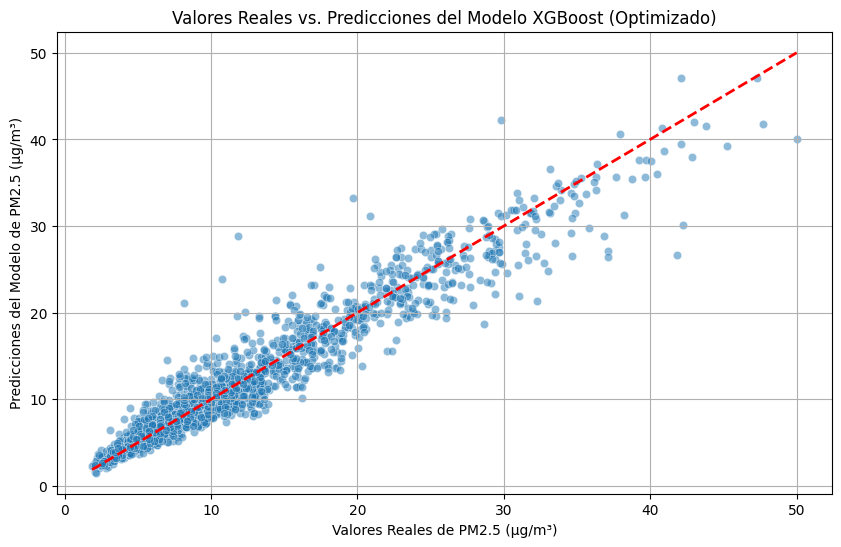

In [3]:
import pandas as pd
import numpy as np
import unicodedata
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Funciones de limpieza y transformación de datos (reutilizadas)
def limpiar_nombres_columnas(df):
    new_columns = []
    for col in df.columns:
        cleaned_name = col.strip().lower()
        cleaned_name = cleaned_name.replace('(', '').replace(')', '')
        cleaned_name = cleaned_name.replace('°', '').replace(' ', '_')
        cleaned_name = cleaned_name.replace('ug/m3', 'ug_m3').replace('%', 'percent')
        cleaned_name = cleaned_name.replace('w/m2', 'w_m2').replace('m/s', 'm_s')
        cleaned_name = cleaned_name.replace('mmhg', 'mm_hg')
        cleaned_name = unicodedata.normalize('NFKD', cleaned_name).encode('ascii', 'ignore').decode('utf-8')
        cleaned_name = cleaned_name.replace('.', '_').replace('/', '_')
        cleaned_name = cleaned_name.replace('__', '_').replace('__', '_').strip('_')
        new_columns.append(cleaned_name)
    df.columns = new_columns
    return df

def manejar_datos_faltantes(df):
    df_processed = df.copy()
    total_rows = len(df_processed)
    cols_to_drop = [col for col in df_processed.columns if df_processed[col].isnull().sum() == total_rows]
    if cols_to_drop:
        df_processed.drop(columns=cols_to_drop, inplace=True)
    df_processed.drop_duplicates(inplace=True)
    for col in df_processed.columns:
        if df_processed[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df_processed[col]):
                median_val = df_processed[col].median()
                df_processed[col] = df_processed[col].fillna(median_val)
            elif df_processed[col].dtype == 'object':
                df_processed[col] = df_processed[col].fillna('DESCONOCIDO')
    return df_processed

def transformar_datos(df):
    df_transformed = df.copy()
    if 'fecha_y_hora' in df_transformed.columns:
        df_transformed['fecha_y_hora'] = pd.to_datetime(df_transformed['fecha_y_hora'], errors='coerce', format='%m/%d/%Y %I:%M:%S %p')
        df_transformed.dropna(subset=['fecha_y_hora'], inplace=True)
        df_transformed['año'] = df_transformed['fecha_y_hora'].dt.year
        df_transformed['mes'] = df_transformed['fecha_y_hora'].dt.month
        df_transformed['dia'] = df_transformed['fecha_y_hora'].dt.day
        df_transformed['hora'] = df_transformed['fecha_y_hora'].dt.hour
    return df_transformed


def main():
    file_path = 'Datasets/SISTEMA_DE_VIGILANCIA_DE_CALIDAD_DE_AIRE.csv'
    
    try:
        df = pd.read_csv(file_path, sep=',', na_values=['NA', '-999'])
    except FileNotFoundError:
        print(f"Error: El archivo '{file_path}' no se encontró.")
        return
        
    print("--- 1. Preparación de Datos ---")
    df_clean = limpiar_nombres_columnas(df.copy())
    df_final = manejar_datos_faltantes(df_clean)
    df_final = transformar_datos(df_final)

    target_column = 'pm2_5_g_m3'
    features = [
        'presion_atmosferica_mm_hg', 'temperatura_ambiente_celsius', 
        'velocidad_del_viento_m_s', 'direccion_del_viento', 'humedad_relativa_percent', 
        'radiacion_solar_w_m2', 'precipitacion_mm', 'o3_g_m3', 'trs_g_m3', 
        'pm10_g_m3'
    ]
    
    X = df_final[features]
    y = df_final[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # ----------------------------------------------------
    # --- 2. Ajuste de Hiperparámetros con GridSearchCV ---
    # ----------------------------------------------------
    print("\n--- 2. Ajuste de Hiperparámetros ---")
    param_grid = {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }

    model = XGBRegressor(objective='reg:squarederror', random_state=42)
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
    
    grid_search.fit(X_train, y_train)
    
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_
    
    print(f"Mejores hiperparámetros encontrados: {best_params}")
    print(f"Mejor puntuación R-squared en validación cruzada: {best_score:.4f}")
    
    # --- 3. Entrenamiento y Evaluación del Modelo Final ---
    print("\n--- 3. Entrenamiento y Evaluación del Modelo Final ---")
    best_model = grid_search.best_estimator_
    predictions = best_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    print(f"MAE (Error Absoluto Medio) en datos de prueba: {mae:.4f}")
    print(f"R-squared (Coeficiente de Determinación) en datos de prueba: {r2:.4f}")

    # Gráfico de evaluación final
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=predictions, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title('Valores Reales vs. Predicciones del Modelo XGBoost (Optimizado)')
    plt.xlabel('Valores Reales de PM2.5 (µg/m³)')
    plt.ylabel('Predicciones del Modelo de PM2.5 (µg/m³)')
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

# Informe de Evaluación y Optimización del Modelo Predictivo de Calidad del Aire

##  Introducción

El objetivo de esta actividad fue construir y optimizar un modelo de Machine Learning para predecir la concentración de partículas finas PM2.5. Para ello, se utilizó un conjunto de datos real que contenía información sobre contaminantes y variables meteorológicas. El modelo de regresión creado busca entender la relación entre estas variables para predecir con precisión los niveles de PM2.5, un dato crucial para la gestión ambiental.

## Metodología de Construcción y Optimización del Modelo

Se utilizó el algoritmo XGBoost Regressor mismo del ejercicio pasado, el cual es un método de ensamble robusto conocido por su alta precisión en datos tabulares. El proceso de construcción y optimización se realizó en las siguientes etapas:

1. **Preparación de Datos:** Se estandarizaron los nombres de las columnas, se eliminaron los datos con el 100% de valores faltantes y se imputaron los valores faltantes restantes con la mediana.

2. **División de Datos:** El conjunto de datos se dividió en un 80% para entrenamiento y un 20% para prueba para evaluar la capacidad del modelo para generalizar a datos no vistos.

3. **Ajuste de Hiperparámetros:** Para optimizar el rendimiento del modelo, se utilizó la técnica de búsqueda por cuadrícula (GridSearchCV) con validación cruzada. Se exploraron diferentes combinaciones de los siguientes hiperparámetros clave para encontrar los valores que minimizan el error del modelo:

    **n_estimators:** Número de árboles de decisión.

    **learning_rate:** Tasa de aprendizaje.

    **max_depth:** Profundidad máxima de cada árbol.

4. **Entrenamiento y Evaluación Final:** Se entrenó el modelo con la mejor combinación de hiperparámetros y se evaluó su rendimiento final en el conjunto de prueba.

**Nota Aclaratoria:** No calculamos precisión, recall, F1-score ya que este es un modelo de regresion y no de clasificación

# Resultados y Análisis

| Métrica | Valor del Modelo Inicial | Valor del Modelo Optimizado |
| :--- | :--- | :--- |
| **MAE** | 1.55 | 1.5252 |
| **R²** | 0.92 | 0.9202 |

* **Optimización de Hiperparámetros:** La búsqueda por cuadrícula identificó los siguientes hiperparámetros óptimos para el modelo: `n_estimators = 200`, `learning_rate = 0.1` y `max_depth = 5`. La puntuación R² de validación cruzada para esta combinación fue de **0.9201**, lo que confirma su solidez.
* **Mejora en el Rendimiento:** Aunque el modelo inicial ya era muy preciso, el ajuste de hiperparámetros logró una mejora sutil pero significativa. El **MAE se redujo** de 1.55 a 1.5252, lo que indica que, en promedio, el error de predicción disminuyó. El **R² aumentó** ligeramente a 0.9202, lo que demuestra que el modelo optimizado explica una fracción ligeramente mayor de la variabilidad en los datos.

## Conclusion


El modelo de regresión basado en XGBoost es una herramienta muy efectiva y confiable para predecir la concentración de PM2.5. El proceso de optimización confirmó que el modelo es robusto y tiene un alto rendimiento. Los resultados del MAE y R² demuestran que el modelo puede ofrecer predicciones de gran precisión, lo cual es invaluable para la toma de decisiones en temas de salud y medio ambiente.